# Taller 04


### Nombre: Erick Cuichan


---

# Parte 1
Verificación visual. 

In [5]:
pts = [(0, -5), (1, -4), (2, 3)]

In [6]:
def Spline(x, xi, *, a, b, c, d):
    return a + b * (x - xi) + c * (x - xi) ** 2 + d * (x - xi) ** 3

In [7]:
def dibujar_spline(pts, s):
    xs, ys = zip(*pts)
    for i, x_i in enumerate(xs[:-1]):
        _x = np.linspace(x_i, xs[i + 1], 20)
        _y = Spline(_x, x_i, **s[i])
        plt.plot(_x, _y)

    plt.scatter(xs, ys)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interpolación con splines cúbicos")
    plt.show()

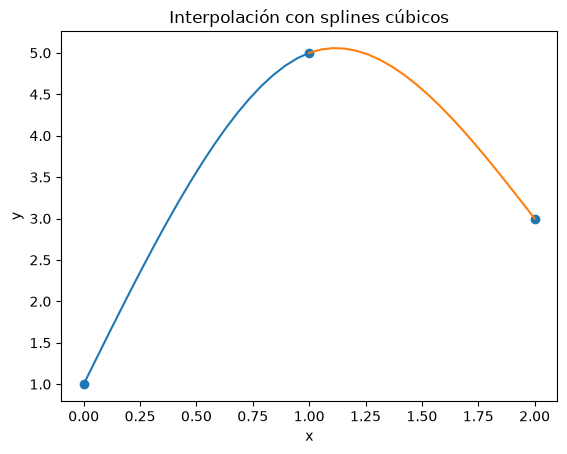

In [8]:
pts = [(0, 1), (1, 5), (2, 3)]

s = [
    {"a": 1, "b": 5.5,"c": 0, "d": -3/2},
    {"a": 5, "b": 1, "c": -9/2, "d": 3/2},
]


dibujar_spline(pts, s)

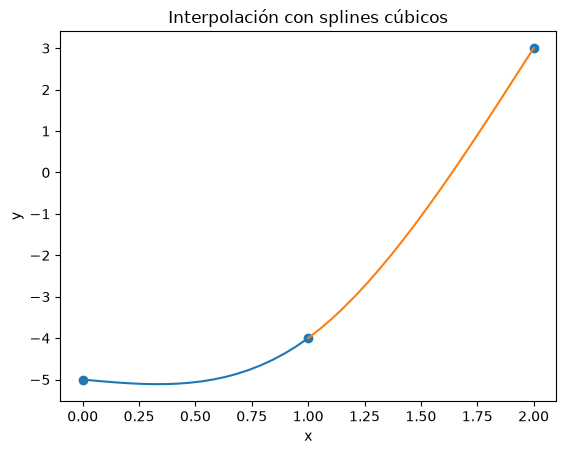

In [9]:
pts = [(0, -5), (1, -4), (2, 3)]

s = [
    {"a": -5, "b": -1/2, "c": 0, "d": 3/2},
    {"a": -4, "b": 4, "c": 9/2, "d": -3/2},
]


dibujar_spline(pts, s)

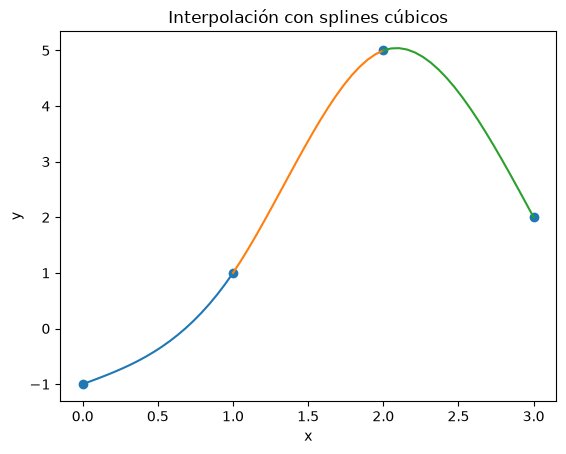

In [10]:
pts = [(0, -1), (1, 1), (2, 5), (3, 2)]

s = [
    {"a": -1, "b": 1, "c": 0, "d": 1},
    {"a": 1, "b": 4, "c": 3, "d": -3},
    {"a": 5, "b": 1, "c": -6, "d": 2},
]


dibujar_spline(pts, s)

---

## Parte 2
Complete la función cubic_spline en el repositorio siguiendo el pseudocódigo para encontrar los splines de frontera natural.  



In [11]:
!pip install sympy

In [12]:
import sympy as sym
from IPython.display import display


# ###################################################################
def cubic_spline(xs: list[float], ys: list[float]) -> list[sym.Symbol]:
    """
    Cubic spline interpolation ``S``. Every two points are interpolated by a cubic polynomial
    ``S_j`` of the form ``S_j(x) = a_j + b_j(x - x_j) + c_j(x - x_j)^2 + d_j(x - x_j)^3.``

    xs must be different  but not necessarily ordered nor equally spaced.

    ## Parameters
    - xs, ys: points to be interpolated

    ## Return
    - List of symbolic expressions for the cubic spline interpolation.
    """

    points = sorted(zip(xs, ys), key=lambda x: x[0])  # sort points by x

    xs = [x for x, _ in points]
    ys = [y for _, y in points]

    n = len(points) - 1  # number of splines

    h = [xs[i + 1] - xs[i] for i in range(n)]  # distances between  contiguous xs



    alpha = [0] * (n + 1)
    for i in range(1, n):
        alpha[i] = 3 / h[i] * (ys[i + 1] - ys[i]) - 3 / h[i - 1] * (ys[i] - ys[i - 1])

    l = [1]
    u = [0]
    z = [0]

    for i in range(1, n):
        l += [2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * u[i - 1]]
        u += [h[i] / l[i]]
        z += [(alpha[i] - h[i - 1] * z[i - 1]) / l[i]]

    l.append(1)
    z.append(0)
    c = [0] * (n + 1)

    x = sym.Symbol("x")
    splines = []
    for j in range(n - 1, -1, -1):
        c[j] = z[j] - u[j] * c[j + 1]
        b = (ys[j + 1] - ys[j]) / h[j] - h[j] * (c[j + 1] + 2 * c[j]) / 3
        d = (c[j + 1] - c[j]) / (3 * h[j])
        a = ys[j]
        print(j, a, b, c[j], d)
        S = a + b * (x - xs[j]) + c[j] * (x - xs[j]) ** 2 + d * (x - xs[j]) ** 3

        splines.append(S)
    splines.reverse()
    return splines

## Verificación de código 

Ejercicio 1  $$(0,1),(1,5),(2,3)$$

In [13]:
splines = cubic_spline(xs=[0,1,2], ys=[1,5,3])
_ = [display(s.expand()) for s in splines]

1 5 1.0 -4.5 1.5
0 1 5.5 0.0 -1.5


-1.5*x**3 + 5.5*x + 1

1.5*x**3 - 9.0*x**2 + 14.5*x - 2.0

Ejercicio 2   $$(0,-5),(1,-4),(2,3)$$

In [14]:
splines = cubic_spline(xs=[0,1,2], ys=[-5,-4,3])
_ = [display(s.expand()) for s in splines]

1 -4 4.0 4.5 -1.5
0 -5 -0.5 0.0 1.5


1.5*x**3 - 0.5*x - 5

-1.5*x**3 + 9.0*x**2 - 9.5*x - 2.0

Ejercicio3   $$(0,-1),(1,1),(2,5),(3,2)$$

In [15]:
splines = cubic_spline(xs=[0,1,2,3], ys=[-1,1,5,2])
_ = [display(s.expand()) for s in splines]

2 5 1.0 -6.0 2.0
1 1 4.0 3.0 -3.0
0 -1 1.0 0.0 1.0


1.0*x**3 + 1.0*x - 1

-3.0*x**3 + 12.0*x**2 - 11.0*x + 3.0

2.0*x**3 - 18.0*x**2 + 49.0*x - 37.0

### PARTE 3

Para cada uno de los ejercicios anteriores, resuelva los splines cúbicos de frontera natural para todos los valores de x2∈R
.
Realice una animación de la variación de los splines cúbicos al variar x2

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from ipywidgets import interact, FloatSlider


def animar_spline(xs_fijos, ys_fijos, y_movil, titulo="Spline cúbico natural",
                  x2_min=1.1, x2_max=5.0):

    x_sym = sym.Symbol("x")

    def graficar(x_2):
        xs = xs_fijos + [x_2]
        ys = ys_fijos + [y_movil]

        splines = cubic_spline(xs, ys)

        pts = sorted(zip(xs, ys), key=lambda p: p[0])
        xs_ord = [p[0] for p in pts]

        plt.figure(figsize=(10, 6))
        for i, S in enumerate(splines):
            f = sym.lambdify(x_sym, S, "numpy")
            xv = np.linspace(xs_ord[i], xs_ord[i+1], 100)
            yv = f(xv)
            if np.isscalar(yv):
                yv = np.full_like(xv, yv)
            plt.plot(xv, yv, 'r', lw=2)

        plt.plot(xs_fijos, ys_fijos, 'go', markersize=8, label='Puntos fijos')
        plt.plot(x_2, y_movil, 'o', color='orange', markersize=12, label='Punto móvil $x_2$')

        plt.xlim(min(xs_fijos)-2, x2_max+1)
        plt.ylim(min(ys_fijos+[y_movil])-5, max(ys_fijos+[y_movil])+4)
        plt.axhline(0, color='black', lw=0.5)
        plt.axvline(0, color='black', lw=0.5)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.title(titulo, fontsize=13)
        plt.xlabel('x'); plt.ylabel('y')
        plt.show()

    interact(
        graficar,
        x_2=FloatSlider(value=(x2_min+x2_max)/2, min=x2_min, max=x2_max,
                        step=0.1, description='$x_2$')
    )

In [ ]:
# Ejercicio 1: (0,1),(1,5),(x₂,3)
animar_spline([0, 1], [1, 5], y_movil=3, titulo="Ejercicio 1: (0,1),(1,5),(x₂,3)")

interactive(children=(FloatSlider(value=3.05, description='$x_2$', max=5.0, min=1.1), Output()), _dom_classes=…

In [ ]:
# Ejercicio 2: (0,-5),(1,-4),(x₂,3)
animar_spline([0, 1], [-5, -4], y_movil=3, titulo="Ejercicio 2: (0,-5),(1,-4),(x₂,3)")

interactive(children=(FloatSlider(value=3.05, description='$x_2$', max=5.0, min=1.1), Output()), _dom_classes=…

In [ ]:
# Ejercicio 3: (0,-1),(1,1),(2,5),(x₂,2)
animar_spline([0, 1, 2], [-1, 1, 5], y_movil=2, titulo="Ejercicio 3", x2_min=2.1, x2_max=6.0)

interactive(children=(FloatSlider(value=4.05, description='$x_2$', max=6.0, min=2.1), Output()), _dom_classes=…